Exercise 1: Duplicate Detection and Removal
====

Instructions
Objective: Identify and remove duplicate entries in the Titanic dataset.

- Load the Titanic dataset.
- Identify if there are any duplicate rows based on all columns.
- Remove any duplicate rows found in the dataset.
- Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.


In [3]:
import pandas as pd

In [26]:
df = pd.read_csv('train.csv')

In [5]:
initial_rows = df.shape[0]
print(f"Initial number of rows: {initial_rows}")

Initial number of rows: 891


Duplicated rows:

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


Removing duplicates:

In [8]:
df = df.drop_duplicates()

Verification:

In [9]:
final_rows = df.shape[0]

print(f"Number of rows after removing duplicated: {final_rows}")
print(f"\nRows removed: {initial_rows - final_rows}")


Number of rows after removing duplicated: 891

Rows removed: 0


Conclusion:


As there was any duplicate row, the initial number of row stayed the same. 

__________________________________

Exercise 2: Handling Missing Values
===
Instructions
- Identify columns in the Titanic dataset with missing values.
- Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
- Apply each strategy to different columns based on the nature of the data.


Checking for missing values:

In [13]:
missing_values = df.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Removing Cabin:

In [14]:
df.drop(columns='Cabin', inplace=True)

Filling with constant value:

In [15]:
df['Embarked'] = df['Embarked'].fillna('S')

Imputation:

In [17]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 16.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 35.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [18]:
from sklearn.impute import SimpleImputer

In [19]:
imputer = SimpleImputer(strategy='median')

df[['Age']] = imputer.fit_transform(df[['Age']])

Verification: 

In [20]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


____________________________

Exercise 3: Feature Engineering
===
Instructions
- Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
- Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
- You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.


Creating a FamilySize:

In [21]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(df[['SibSp', 'Parch', 'FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


Title extracted from the Name column:

In [28]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/11/01wml45d32l3bgdl2z4gyjth0000gn/T/ipykernel_52415/2205265257.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Label Encoding:

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

Turning "Embarked" into Numbers:

In [29]:
df = pd.get_dummies(df, columns=['Embarked'])

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,Mr,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,Mrs,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Miss,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,Mrs,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,Mr,False,False,True


_________________________________

Exercise 4: Outlier Detection and Handling
====
Goal: Detect and cap or transform outliers in columns like Fare and Age.

1. Visualize distributions using boxplots or histograms to identify potential outliers.
2. Use IQR or Z-score methods to detect them.
3. Handle outliers with:

Quantile capping (e.g. 0.98)
Log transformation
Row removal
4. Compare the dataset before and after treatment.

📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.

In [32]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 10.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.2 MB/s  0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 12.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [33]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [35]:
import seaborn as sns

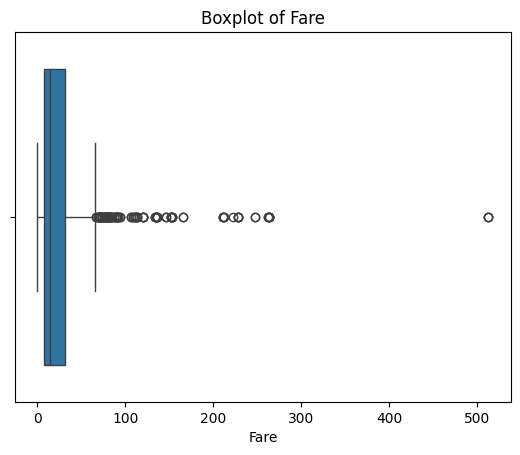

In [36]:
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare')
plt.show()

Detecting Outliers using IQR:

In [37]:
Q1 = df['Fare'].quantile(0.25) 
Q3 = df['Fare'].quantile(0.75) 
IQR = Q3 - Q1                 

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower_fence) | (df['Fare'] > upper_fence)]
print(f"Number of outliers detected: {len(outliers)}")

Number of outliers detected: 116


Handling Outliers:

In [38]:
upper_limit = df['Fare'].quantile(0.98)

df['Fare'] = df['Fare'].clip(upper=upper_limit)

Comparison:

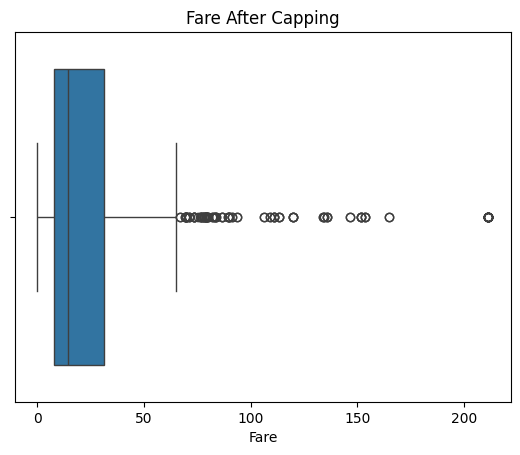

In [39]:
sns.boxplot(x=df['Fare'])
plt.title('Fare After Capping')
plt.show()

_______________________

Exercise 5: Data Standardization and Normalization
===
Goal: Scale numerical features to prepare for modeling.

- Use StandardScaler (mean = 0, std = 1) for normally distributed features.
- Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
📌 Important: Perform this step after outlier treatment to avoid distortion caused by extreme values.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age']] = scaler.fit_transform(df[['Age']])

In [41]:
from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler()

df[['Fare']] = min_max.fit_transform(df[['Fare']])

__________________________

Exercise 6: Feature Encoding
===
Goal: Finalize categorical variable encoding.

1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
2. Apply:

One-Hot Encoding for nominal variables.
Label Encoding if any ordinal variables remain.
3. Merge encoded columns back into the main dataset.


In [42]:
print(df.select_dtypes(include=['object']).columns)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Title'], dtype='str')


/var/folders/11/01wml45d32l3bgdl2z4gyjth0000gn/T/ipykernel_52415/845905018.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns)


In [43]:
df = pd.get_dummies(df, columns=['Title'], prefix='Title')

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

Cleanup:

In [45]:
df.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True, errors='ignore')

print(df.dtypes)

PassengerId         int64
Survived            int64
Pclass              int64
Sex                 int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Embarked_C           bool
Embarked_Q           bool
Embarked_S           bool
Title_Capt           bool
Title_Col            bool
Title_Countess       bool
Title_Don            bool
Title_Dr             bool
Title_Jonkheer       bool
Title_Lady           bool
Title_Major          bool
Title_Master         bool
Title_Miss           bool
Title_Mlle           bool
Title_Mme            bool
Title_Mr             bool
Title_Mrs            bool
Title_Ms             bool
Title_Rev            bool
Title_Sir            bool
dtype: object


In [46]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,1,0,3,1,-0.530377,1,0,0.034305,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,1,1,0,0.571831,1,0,0.337296,True,False,...,False,False,False,False,False,False,True,False,False,False
2,3,1,3,0,-0.254825,0,0,0.037499,False,False,...,False,False,True,False,False,False,False,False,False,False
3,4,1,1,0,0.365167,1,0,0.251257,False,False,...,False,False,False,False,False,False,True,False,False,False
4,5,0,3,1,0.365167,0,0,0.038091,False,False,...,False,False,False,False,False,True,False,False,False,False


________________________

Exercise 7: Data Transformation for Age Feature
===
Goal: Create and encode age groups.

- Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
- Apply one-hot encoding using pd.get_dummies().
📌 Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.

In [47]:
age_bins = [0, 12, 18, 60, 100]

age_labels = ['Child', 'Teen', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

print(df[['Age', 'AgeGroup']].head())

        Age AgeGroup
0 -0.530377      NaN
1  0.571831    Child
2 -0.254825      NaN
3  0.365167    Child
4  0.365167    Child


Converting AgeGroup to different columns:

In [51]:
cols_to_fix = ['Age_Child', 'Age_Teen', 'Age_Adult', 'Age_Senior']
df.drop(columns=cols_to_fix, errors='ignore', inplace=True)

real_ages = scaler.inverse_transform(df[['Age']])

age_bins = [0, 12, 18, 60, 100]
age_labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(real_ages.flatten(), bins=age_bins, labels=age_labels)

df = pd.get_dummies(df, columns=['AgeGroup'], prefix='Age', dtype=int)

print(df.filter(like='Age').head())

        Age  Age_Child  Age_Teen  Age_Adult  Age_Senior
0 -0.530377          0         0          1           0
1  0.571831          0         0          1           0
2 -0.254825          0         0          1           0
3  0.365167          0         0          1           0
4  0.365167          0         0          1           0


In [52]:
print(real_ages.flatten()[:5])

[22. 38. 26. 35. 35.]


How many people are in each category in total?

In [53]:
print(df[['Age_Child', 'Age_Teen', 'Age_Adult', 'Age_Senior']].sum())

Age_Child      69
Age_Teen       70
Age_Adult     553
Age_Senior     22
dtype: int64
